Libraries

In [1]:
import os
import sys
sys.path.append('/dataset/')
sys.path.append("../src_re") 

import math
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import parameters_to_vector
from scipy.linalg import eig, inv
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils.stateless import functional_call
from tensorboard import notebook
from datetime import datetime
from tqdm import tqdm
import wandb

# KAE
from Autoencoder import KoopmanAutoencoder
from Autoencoder_functions import *
from state_extract import *

# Cartpole
from test_cartpole_function_MPC import *
from models.MLP import CartpoleMLP



Parameters

In [2]:
# Use GPU
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda:0')
print('Currently using... '+str(device))

# Load pre-trained KAE?
load_model = True
load_model_name = "KAE_[4, 64, 32, 0.5, -1, 0.5, 2, 'CARTPOLE_v1']_2025-09-25.pth"

# KAE parameters
observable_dim = 4 # observable dim
padded_dimension = 64 # MUST BE BIGGER THAN ANY STATE DIMENSION (INPUT, OUPTUT, INTERNAL)
kae_size = 32 # size of KAE
c1, c2, c3 = 1, 1, 1 # KAE loss parameters
p = 2 # KAE prediction step
loss_dist_mc_sample_num = 5 # number of MC integral samples
### -------------------- Loss coefficient
kae_coef = 0.5
# task_coef = 1/10000
task_coef = -1 # NO LOSS_TASK NOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
eig_coef = -0.5
dist_coef = 0.5

# Data & Training parameter
training_data_generation_loop = 15000 # how many loop you will run to generate the data
                                      # NOT NUMBER OF TRAINING DATA: that is 'training_data_size'
batch_size = 128 # 128
lr_kae = 1e-3
num_epochs = 5000
num_episodes_for_loss_task = 5 # test number during training (=validation set)
waypoint_period = 5 # Check score every this epoch and update waypoint
check_performance = False # Check performance before update the waypoint?
clip = True # clip gradient norm?

# Cartpole parameters
original_model_name = 'ppo_cartpole_policy.pt'
state_bound_lo = torch.tensor([-4.8, -10, -0.418, -3.0], device=device) # pos, vel, angle, angluar vel
state_bound_hi = torch.tensor([ 4.8,  10,  0.418,  3.0], device=device) # pos, vel, angle, angluar vel
env = gym.make("CartPole-v1")
num_episodes = 20 # test number for validation
max_reward = 500 # possible maximum reward
reward_margin = max_reward*0.01 # allow this much reward decrease

# INitialization
training_data_size = training_data_generation_loop*p # size of training dataset
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
Info = [observable_dim, padded_dimension, kae_size, kae_coef, eig_coef, dist_coef, p, 'CARTPOLE_v1']
print('obs dim: '+str(obs_dim) + ' / act dim: '+str(act_dim))
if padded_dimension < obs_dim or padded_dimension < act_dim:
    print('ERROR, PADDED DIMENSION MUST BE BIGGER')
    exit()

original_model = CartpoleMLP(obs_dim, act_dim).to(device)

Currently using... cuda:0
obs dim: 4 / act dim: 2


In [3]:
## Set training to be deterministic
seed = 10
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(seed)

## LOAD TRAINED MODEL
if os.path.isfile('../saved_models_re/originals/'+original_model_name):
    state_dict = torch.load('../saved_models_re/originals/'+original_model_name, weights_only=True, map_location=device)
    original_model.load_state_dict(state_dict)
    print('load '+original_model_name)
    
    # TEST PERFORMANCE OF LOADED MODEL
    # print('testing model')
    # test_cartpole_function('../saved_models_re/originals/'+original_model_name, save_imgs=False)

else:
    print('ERROR, NO MODEL FOUND')

## Build KAE
state_dim = padded_dimension
kae = KoopmanAutoencoder(state_dim=state_dim, hidden_dim=kae_size, observable_dim = observable_dim, device=device).to(device)
criterion_kae = koopman_loss
mse = torch.nn.MSELoss()
optimizer_kae = optim.Adam(kae.parameters(), lr=lr_kae)

kae = torch.load('results/'+load_model_name, weights_only=False, map_location=device)
# kae.load_state_dict(torch.load("results/"+load_model_name))
kae.to(device)
kae.eval()
print('model loaded')

load ppo_cartpole_policy.pt
Tanh ver
model loaded


Koopman Autoencoder MPC


/home/joonwon/github/Koopman_decompose_ext/KAE/Autoencoder_functions.py:276: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3725.)
  eigvals = eigvals.conj().T


IndexError: list index out of range

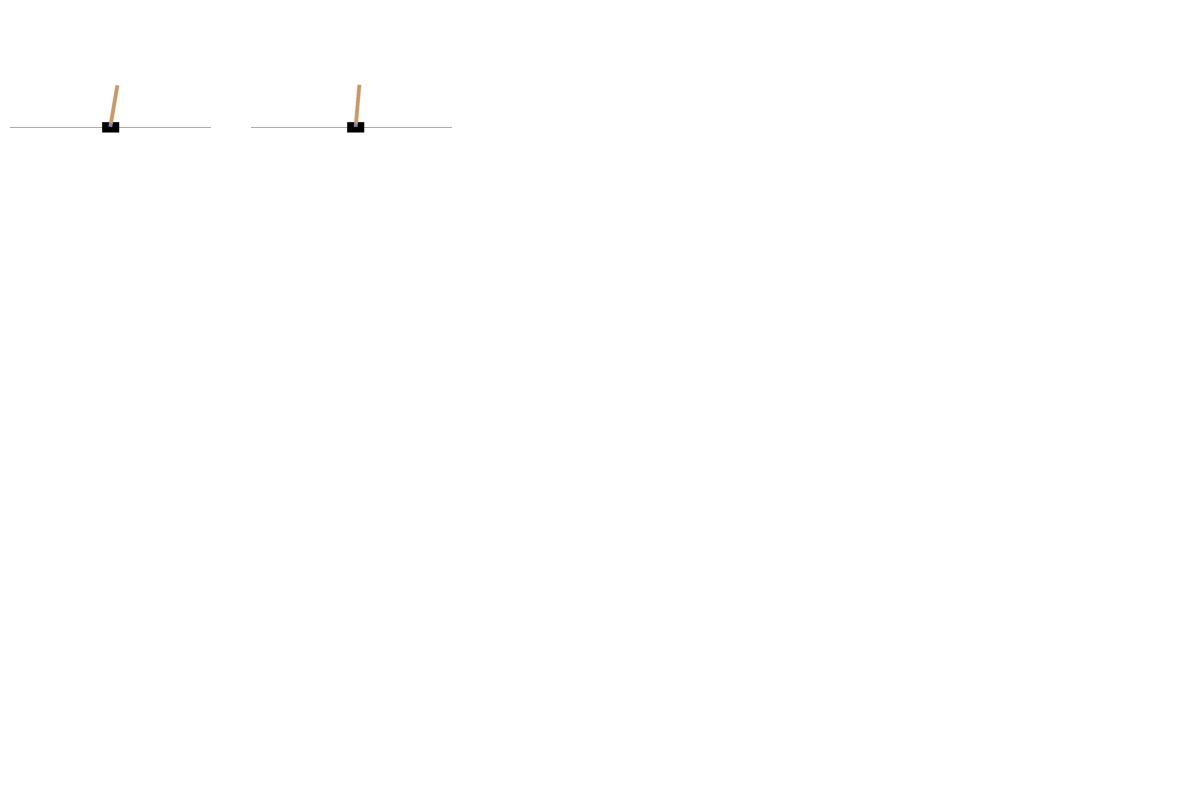

In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from Autoencoder import *
from Autoencoder_functions import *
from test_cartpole_function import *

## CHECK RECONSTRUCTION AND MODE PERFORMANCE

# print('Original model')
# test_cartpole_function('../saved_models_re/originals/'+original_model_name, save_imgs=True)

with torch.no_grad():
    kae.eval()
    print('Koopman Autoencoder MPC')
    reward = test_cartpole_kae_function_MPC(kae, observable_dim, padded_dimension, p, device, T=3, num_episodes = num_episodes, save_imgs = True)


In [ ]:
test_K = kae.K
val, _ = torch.linalg.eig(test_K)
print(val.abs())

tensor([0.9941, 0.9171, 0.0012, 0.0086], device='cuda:0',
       grad_fn=<AbsBackward0>)


In [ ]:
## UNDER CONSTRUCTION BELOW ###############################

import importlib
from Autoencoder_functions import *

%load_ext autoreload
%autoreload 2

sorted_labels, sorted_indices = torch.sort(all_test_labels)
all_test_images_sorted = all_test_images[sorted_indices]
all_test_labels_sorted = sorted_labels
per_label_test_images = {i: all_test_images[all_test_labels == i] for i in range(num_classes)}
per_label_test_labels = {i: all_test_labels[all_test_labels == i] for i in range(num_classes)}

with torch.no_grad():
    for j in range(0,observable_dim):
        result = []
        for cc in range(0,num_classes):
            reconstructed_output_wo_pad = []
            # reconstructed_output_prop_wo_pad = []
            for i in range(0,len(per_label_test_images[cc])):
                _,z,_ = kae(all_test_images[i,:])
                z_next = torch.matmul(z, kae.K.T)
                reconstructed_output = stt_decompose_mode(kae, z, z_next, observable_dim, j, propagation=True)
                reconstructed_output_wo_pad.append(reconstructed_output[:num_classes])

            reconstructed_output_wo_pad = torch.stack(reconstructed_output_wo_pad)
            reconstructed_output_wo_pad_real = reconstructed_output_wo_pad.real.detach()
            predicted = torch.argmax(reconstructed_output_wo_pad_real, dim=1)
            # print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
            correct = (predicted == per_label_test_labels[cc]).sum().item()
            total = all_test_labels.size(0)
            accuracy = 100.0 * correct / total
            result.append(accuracy)
        print(str(j)+"-th mode "+str(result))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


NameError: name 'all_test_labels' is not defined

In [ ]:

print()

predicted = torch.argmax(reconstructed_output_wo_pad, dim=1)
print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
print(np.shape(predicted))
correct = (predicted == all_test_labels).sum().item()
total = all_test_labels.size(0)
accuracy = 100.0 * correct / total
print(accuracy)

In [ ]:

    for idx_modes in tqdm(range(kae_size)):
        temp = np.zeros(num_classes)
        
        for idx_sub in range(num_classes):
            param_sub = param_sub_all[:, idx_modes]
            if target_dataset == 'MNIST_DEEP':
                classifier_sub_test = deepdeeper_MLP(image_size, hidden_c, num_classes).to(device)
            else:   
                classifier_sub_test = deeper_MLP(image_size, hidden_c, num_classes).to(device)
            classifier_sub_test.eval()
            nn.utils.vector_to_parameters(param_sub, classifier_sub_test.parameters())
            testloader = dataset_in_use_per_class.sub_testloaders[idx_sub]
            total = 0
            correct = 0
            for images, labels in testloader:
                images = images.reshape(-1, 28*28).to(device)
                labels = labels.to(device)
                outputs = classifier_sub_test(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            accuracy = 100 * correct / total
            temp[idx_sub] = accuracy
        formatted = np.array([num for num in temp])

        if idx_modes == 0:
            formatted_history = formatted
        else:
            formatted_history = np.vstack((formatted_history, formatted))

# Get best element
formatted_history2 = np.array(formatted_history, dtype=float)
bests = np.max(formatted_history2,axis = 0)
is_max = formatted_history2 == bests
row_counts = np.sum(is_max, axis = 1)

print('Best elements :')
print(bests)
print('Best counts :')
print(row_counts)

num_cols = formatted_history2.shape[1]
for col in range(num_cols):
    rows_with_max = np.where(formatted_history2[:,col] == bests[col])[0]
    print('------------')
    print(f'Class {col}: Best = {bests[col]}')
    for row_idx in rows_with_max:
        print(f'Mode {row_idx}: [|eig|={torch.linalg.norm(eigvals_d[row_idx])}] {np.array2string(formatted_history2[row_idx], precision=4)}')